# Job Market Intelligence – Exploratory Data Analysis

This notebook explores the cleaned No Fluff Jobs dataset to identify patterns in job demand, experience levels, workplace models, contract types, salaries, and technologies.

In [1]:
from pathlib import Path
import pandas as pd

import plotly.express as px

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "nofluff_it_jobs_clean.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (2856, 31)


## Analysis plan

The exploratory analysis focuses on four main questions:

1. What experience levels are most in demand?
2. What workplace models and contract types are most common?
3. How do salaries differ across experience levels and job categories?
4. Which technologies and skills are most frequently required?

## 1. Dataset overview

This section provides a high-level overview of the dataset, including the number
of job offers, companies, categories, salary availability, and data collection period.


In [2]:
# Convert scraping date to datetime
df["scraped_at"] = pd.to_datetime(
    df["scraped_at"],
    errors="coerce"
)

overview = pd.Series({
    "Job offers": len(df),
    "Unique companies": df["company"].nunique(),
    "Unique job titles": df["title"].nunique(),
    "Unique categories": df["category"].nunique(),
    "Offers with salary": df["salary_min"].notna().sum(),
    "Salary analysis eligible": df["salary_analysis_eligible"].sum(),
})

overview

Job offers                  2856
Unique companies             358
Unique job titles           2318
Unique categories             53
Offers with salary          2622
Salary analysis eligible    1470
dtype: int64

In [3]:
salary_available_pct = (
    df["salary_min"].notna().mean() * 100
)

salary_eligible_pct = (
    df["salary_analysis_eligible"].mean() * 100
)

print(
    f"Offers with salary: "
    f"{salary_available_pct:.1f}%"
)

print(
    f"Offers eligible for salary analysis: "
    f"{salary_eligible_pct:.1f}%"
)

print()
print(
    "Data collection period:",
    df["scraped_at"].min().date(),
    "to",
    df["scraped_at"].max().date()
)

Offers with salary: 91.8%
Offers eligible for salary analysis: 51.5%

Data collection period: 2026-08-23 to 2026-08-23


In [4]:
df[
    [
        "title",
        "company",
        "experience",
        "workplace",
        "salary_min",
        "salary_max"
    ]
].head()

,title,company,experience,workplace,salary_min,salary_max
0,Administrator IT,iteo S.A.,Mid,NaN,10000.0,13000.0
1,Administrator/-ka Aplikacji Biznesowych - Depa...,T-Mobile Polska,Mid,Hybrid,11928.0,15960.0
2,Administrator/ka IT,IMA POLSKA SPÓŁKA AKCYJNA,Mid,Onsite,9900.0,13900.0
3,ADMINISTRATOR SAP BASIS (k/m),MODIVO PLATFORM,Mid,Onsite,38000.0,45000.0
4,Administrator Systemów Linux/BSD (z elementami...,Fudo Security,Mid,Hybrid,72.0,96.0


### Key observations

- The cleaned dataset contains 2,856 unique job offers.
- It includes 358 distinct company names before company-name normalization and 2,318 unique job titles.
- Salary information is available for 91.8% of offers.
- 51.5% of offers meet the conservative criteria used for monthly PLN salary analysis.
- The offers were collected on August 23, 2026.
- The dataset contains 53 raw category values. Some offers belong to multiple job categories.
- A total of 430 expired offers were removed during data preparation because their detailed content was unavailable or potentially unreliable.

## 2. Experience level

This section examines the distribution of job offers across different experience levels.

In [5]:
experience_counts = (
    df["experience"]
    .value_counts(dropna=False)
    .to_frame("job_offers")
)

experience_counts

,job_offers
experience,
Senior,1485
Mid,1040
Junior,121
Expert,118
NaN,92


In [6]:
experience_summary = (
    df["experience"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("experience")
    .reset_index(name="job_offers")
)

experience_summary["percentage"] = (
    experience_summary["job_offers"]
    / len(df)
    * 100
).round(1)

experience_summary

,experience,job_offers,percentage
0,Senior,1485,52.0
1,Mid,1040,36.4
2,Junior,121,4.2
3,Expert,118,4.1
4,Missing,92,3.2


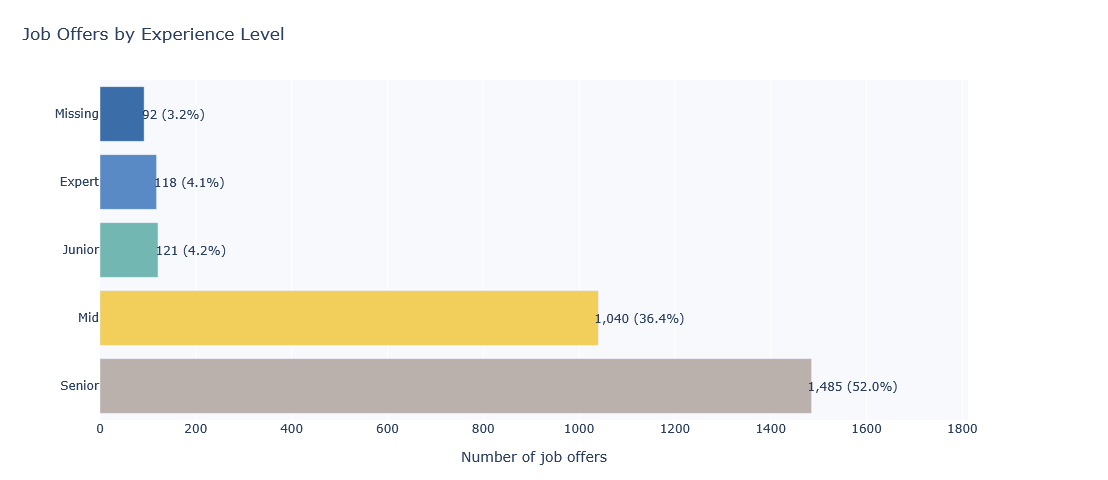

In [7]:
experience_order = [
    "Senior",
    "Mid",
    "Junior",
    "Expert",
    "Missing",
]

experience_summary = (
    df["experience"]
    .fillna("Missing")
    .value_counts()
    .reindex(
        experience_order,
        fill_value=0,
    )
    .rename_axis("experience")
    .reset_index(name="job_offers")
)

experience_summary["percentage"] = (
    experience_summary["job_offers"]
    / len(df)
    * 100
).round(1)

experience_summary["label"] = (
    experience_summary["job_offers"]
    .map(lambda value: f"{value:,}")
    + " ("
    + experience_summary["percentage"].map(
        lambda value: f"{value:.1f}%"
    )
    + ")"
)

fig = px.bar(
    experience_summary,
    x="job_offers",
    y="experience",
    orientation="h",
    text="label",
    category_orders={
        "experience": list(
            reversed(experience_order)
        )
    },
    title="Job Offers by Experience Level",
    labels={
        "job_offers": "Number of job offers",
        "experience": "Experience level",
    },
    color="experience",
    color_discrete_sequence=[
        "#3B6EA8",
        "#5A8AC6",
        "#72B7B2",
        "#F2CF5B",
        "#BAB0AC",
    ],
)

fig.update_traces(
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Job offers: %{x:,}"
        "<extra></extra>"
    ),
)

fig.update_layout(
    width=1000,
    height=480,
    showlegend=False,
    plot_bgcolor="#F7F9FC",
    title=dict(
        x=0.02,
        xanchor="left",
    ),
    xaxis=dict(
        title="Number of job offers",
        range=[
            0,
            experience_summary["job_offers"].max() * 1.22,
        ],
        gridcolor="white",
        zeroline=False,
    ),
    yaxis=dict(
        title=None,
    ),
    margin=dict(
        l=100,
        r=140,
        t=80,
        b=60,
    ),
)

fig.show()

In [8]:
df['experience_years_min'].describe()

count    1437.000000
mean        4.768963
std         1.959779
min         1.000000
25%         3.000000
50%         5.000000
75%         5.000000
max        15.000000
Name: experience_years_min, dtype: float64

In [9]:
df.groupby('experience')['experience_years_min'].describe()

,count,mean,std,min,25%,50%,75%,max
experience,,,,,,,,
Expert,61.0,6.672131,2.378524,3.0,5.0,7.0,8.0,15.0
Junior,39.0,3.128205,2.117341,1.0,2.0,2.0,5.0,10.0
Mid,514.0,3.747082,1.747803,1.0,3.0,3.0,5.0,10.0
Senior,822.0,5.347932,1.671022,1.0,5.0,5.0,6.0,15.0


In [10]:
experience_years = (
    df.groupby("experience")["experience_years_min"]
    .agg(
        job_offers="count",
        median_years="median",
        mean_years="mean"
    )
    .round(1)
)

experience_years

,job_offers,median_years,mean_years
experience,,,
Expert,61,7.0,6.7
Junior,39,2.0,3.1
Mid,514,3.0,3.7
Senior,822,5.0,5.3


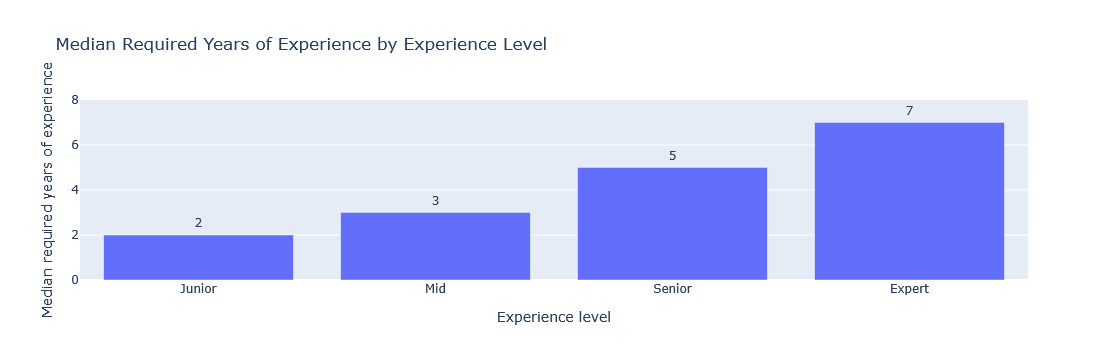

In [11]:

experience_order = [
    "Junior",
    "Mid",
    "Senior",
    "Expert"
]

median_experience = (
    df.groupby("experience")["experience_years_min"]
    .median()
    .reindex(experience_order)
    .reset_index()
)

fig = px.bar(
    median_experience,
    x="experience",
    y="experience_years_min",
    text="experience_years_min",
    title="Median Required Years of Experience by Experience Level",
    labels={
        "experience": "Experience level",
        "experience_years_min": "Median required years"
    }
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    showlegend=False,
    yaxis_title="Median required years of experience",
    xaxis_title="Experience level"
)

fig.update_yaxes(
    range=[0, 8]
)

fig.show()

## 3. Workplace Models

This section examines the distribution of remote, hybrid and onsite job offers and compares workplace models across experience levels.

In [12]:
workplace_summary = (
    df["workplace"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("workplace")
    .reset_index(name="job_offers")
)

workplace_summary["percentage"] = (
    workplace_summary["job_offers"]
    / len(df)
    * 100
).round(1)

workplace_summary

,workplace,job_offers,percentage
0,Hybrid,1532,53.6
1,Remote,991,34.7
2,Missing,323,11.3
3,Onsite,10,0.4


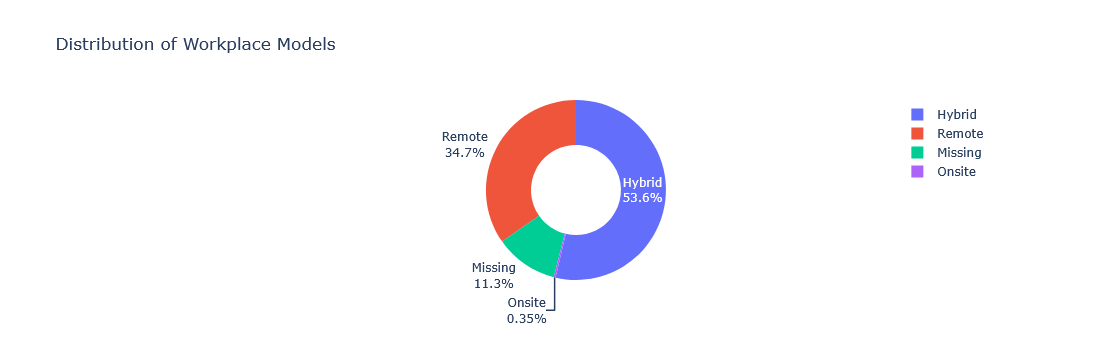

In [13]:
fig = px.pie(
    workplace_summary,
    names="workplace",
    values="job_offers",
    hole=0.5,
    title="Distribution of Workplace Models"
)

fig.update_traces(
    textinfo="percent+label",
    insidetextorientation="horizontal"
)

fig.show()

In [14]:
workplace_experience = (
    pd.crosstab(
        df["experience"],
        df["workplace"].fillna("Missing"),
        normalize="index"
    )
    * 100
).round(1)

workplace_experience

workplace,Hybrid,Missing,Onsite,Remote
experience,,,,
Expert,69.5,1.7,0.0,28.8
Junior,63.6,17.4,0.0,19.0
Mid,57.9,12.8,0.9,28.5
Senior,50.8,6.4,0.0,42.8


In [15]:
workplace_experience_plot = (
    workplace_experience
    .reset_index()
    .melt(
        id_vars="experience",
        var_name="workplace",
        value_name="percentage"
    )
)

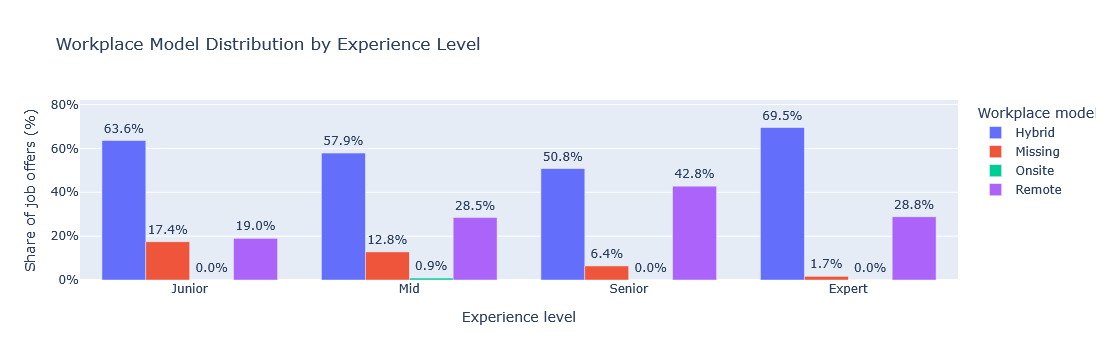

In [16]:
fig = px.bar(
    workplace_experience_plot,
    x="experience",
    y="percentage",
    color="workplace",
    text="percentage",
    barmode="group",
    category_orders={
        "experience": [
            "Junior",
            "Mid",
            "Senior",
            "Expert"
        ]
    },
    title="Workplace Model Distribution by Experience Level",
    labels={
        "experience": "Experience level",
        "percentage": "Share of job offers (%)",
        "workplace": "Workplace model"
    }
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside"
)

fig.update_layout(
    yaxis_ticksuffix="%"
)

fig.show()

### Key observations

Senior and Mid-level positions dominate the dataset, accounting for 88.4% of all job offers. Senior roles represent 52.0% of the market, while Mid-level positions account for 36.4%.

Junior positions represent only 4.2% of offers, which indicates relatively limited opportunities for candidates entering the IT job market. Expert roles account for 4.1%, while the experience level is missing for 3.2% of offers.

Hybrid work is the most common workplace model, representing 53.6% of all offers. Fully remote positions account for 34.7%, while workplace information is missing for 11.3% of records. Onsite offers represent only 0.4%, although this unusually low share may partly reflect limitations in automatic workplace parsing.

Workplace flexibility differs across experience levels. Remote work accounts for 42.8% of Senior offers, compared with 28.5% of Mid-level and 19.0% of Junior offers. Junior candidates are much more likely to encounter hybrid roles, which represent 63.6% of Junior offers.

Overall, the results suggest that recruitment activity on No Fluff Jobs is strongly oriented toward experienced professionals. Candidates with more experience also appear to have greater access to fully remote opportunities, while entry-level candidates face both fewer available positions and a stronger preference for hybrid work.

## 4. Job categories

This section explores the distribution of job offers across different job categories.

Some offers contain multiple categories, so the initial analysis focuses on the raw category values before deciding whether they should be split into separate categories.

In [17]:
top_categories = (
    df["category"]
    .fillna("Missing")
    .value_counts()
    .head(20)
    .rename_axis("category")
    .reset_index(name="job_offers")
)

top_categories

,category,job_offers
0,Backend,252
1,Missing,218
2,Data,211
3,DevOps,208
4,Testing,175
5,"Java, Backend",171
6,ERP,169
7,Project Manager,159
8,Security,147
9,Architecture,126


In [18]:
categories_exploded = (
    df[["job_id", "category"]]
    .dropna(subset=["category"])
    .assign(
        category=lambda x:
        x["category"].str.split(",")
    )
    .explode("category")
)

categories_exploded["category"] = (
    categories_exploded["category"]
    .str.strip()
)

In [19]:
top_categories_exploded = (
    categories_exploded["category"]
    .value_counts()
    .head(20)
    .rename_axis("category")
    .reset_index(name="job_offers")
)

top_categories_exploded

,category,job_offers
0,Backend,536
1,Data,284
2,Java,267
3,Python,261
4,DevOps,248
5,Testing,227
6,Fullstack,204
7,ERP,170
8,AI,169
9,Project Manager,161


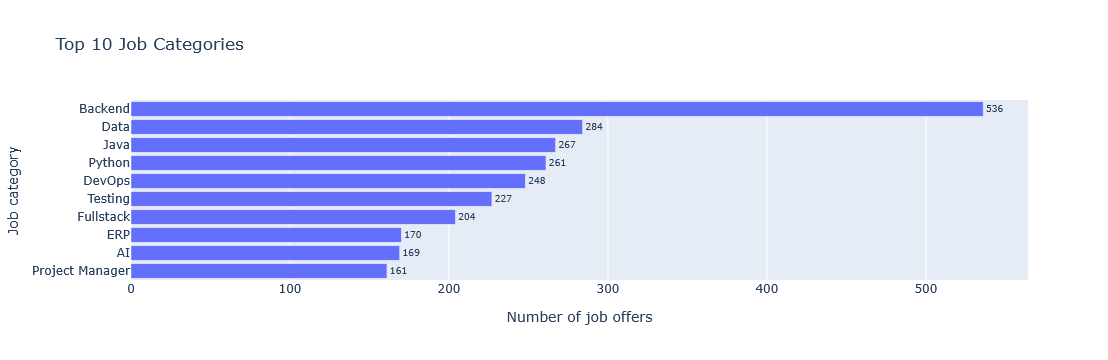

In [20]:
top_10_categories = (
    top_categories_exploded
    .head(10)
    .sort_values(
        "job_offers",
        ascending=True
    )
)

fig = px.bar(
    top_10_categories,
    x="job_offers",
    y="category",
    orientation="h",
    text="job_offers",
    title="Top 10 Job Categories",
    labels={
        "job_offers": "Number of job offers",
        "category": "Job category"
    }
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    showlegend=False
)

fig.show()

In [21]:
top_10_category_names = (
    top_categories_exploded
    .head(10)["category"]
    .tolist()
)

category_experience_df = (
    categories_exploded
    .merge(
        df[
            [
                "job_id",
                "experience"
            ]
        ],
        on="job_id",
        how="left"
    )
)

category_experience_df = (
    category_experience_df[
        category_experience_df["category"]
        .isin(top_10_category_names)
    ]
    .dropna(subset=["experience"])
)

In [22]:
category_experience = (
    pd.crosstab(
        category_experience_df["category"],
        category_experience_df["experience"],
        normalize="index"
    )
    * 100
).round(1)

category_experience = (
    category_experience
    .reindex(
        index=top_10_category_names,
        columns=[
            "Junior",
            "Mid",
            "Senior",
            "Expert"
        ],
        fill_value=0
    )
)

category_experience

experience,Junior,Mid,Senior,Expert
category,,,,
Backend,4.4,29.9,62.7,2.9
Data,4.0,34.7,54.2,7.2
Java,4.9,26.4,66.8,1.9
Python,2.7,27.6,65.8,3.9
DevOps,2.9,34.6,60.1,2.5
Testing,7.3,49.3,41.6,1.8
Fullstack,1.0,33.3,62.6,3.0
ERP,2.4,43.0,49.7,4.8
AI,4.3,25.8,62.6,7.4


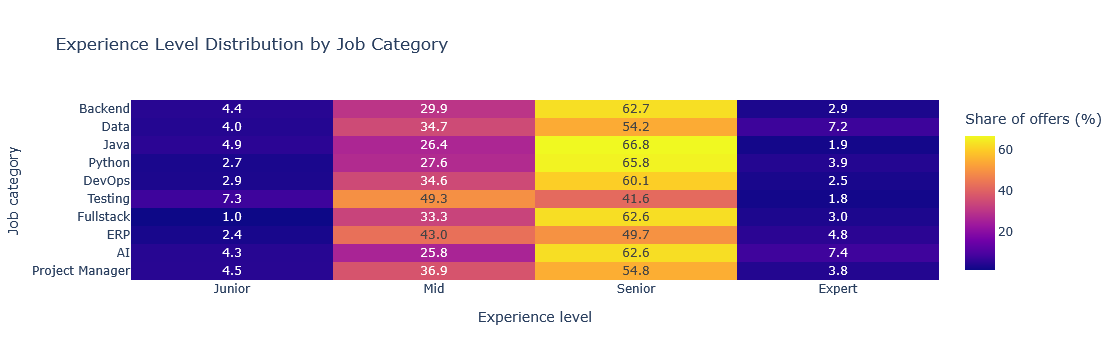

In [23]:
fig = px.imshow(
    category_experience,
    text_auto=".1f",
    aspect="auto",
    title="Experience Level Distribution by Job Category",
    labels={
        "x": "Experience level",
        "y": "Job category",
        "color": "Share of offers (%)"
    }
)

fig.show()

### Key observations

Backend is the most frequently represented job category, with 536 offers. It appears almost twice as often as Data, the second-largest category with 284 offers. Java, Python and DevOps also rank among the most common areas of recruitment.

Senior positions dominate most of the leading categories. They account for approximately two-thirds of Java and Python offers and more than 60% of Backend, Fullstack, DevOps and AI positions.

Testing differs from the other categories: Mid-level roles represent 49.3% of Testing offers, while Senior positions account for 41.6%. Testing also has the highest Junior share among the Top 10 categories, at 7.3%.

Junior opportunities remain limited across all major categories. Their share ranges from only 1.0% in Fullstack to 7.3% in Testing. This indicates that none of the leading categories provides a large proportion of entry-level positions.

AI and Data have the highest shares of Expert-level roles, at 7.4% and 7.2% respectively. This may reflect the specialized knowledge required in these areas.

## 5. Contract types

This section examines the distribution of employment contract types across job offers.

The initial analysis uses the original contract values, including offers that provide multiple contract options. Missing contract information is also included to show the completeness of the data.

In [24]:
df['contract_type'].unique()

array(['B2B', nan, 'B2B, Umowa o pracę', 'Umowa o pracę',
       'B2B, Umowa zlecenie', 'Umowa zlecenie',
       'Umowa o pracę, Umowa zlecenie'], dtype=object)

In [25]:
contract_type_summary = (
    df["contract_type"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("contract_type")
    .reset_index(name="job_offers")
)

contract_type_summary["percentage"] = (
    contract_type_summary["job_offers"]
    / len(df)
    * 100
).round(1)

contract_type_summary

,contract_type,job_offers,percentage
0,B2B,1840,64.4
1,Missing,712,24.9
2,"B2B, Umowa o pracę",199,7.0
3,Umowa o pracę,101,3.5
4,Umowa zlecenie,2,0.1
5,"B2B, Umowa zlecenie",1,0.0
6,"Umowa o pracę, Umowa zlecenie",1,0.0


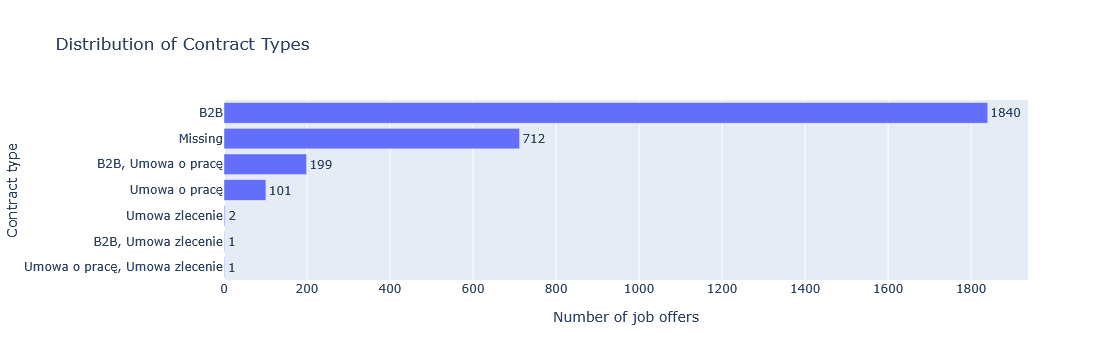

In [26]:
contract_type_plot = (
    contract_type_summary
    .sort_values(
        "job_offers",
        ascending=True
    )
)

fig = px.bar(
    contract_type_plot,
    x="job_offers",
    y="contract_type",
    orientation="h",
    text="job_offers",
    title="Distribution of Contract Types",
    labels={
        "job_offers": "Number of job offers",
        "contract_type": "Contract type"
    }
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    showlegend=False
)

fig.show()

In [27]:
experience_order = [
    "Junior",
    "Mid",
    "Senior",
    "Expert"
]

contract_experience = (
    pd.crosstab(
        df["experience"],
        df["contract_type"].fillna("Missing"),
        normalize="index"
    )
    * 100
).round(1)

contract_experience = (
    contract_experience
    .reindex(experience_order)
)

contract_experience

contract_type,B2B,"B2B, Umowa o pracę","B2B, Umowa zlecenie",Missing,Umowa o pracę,"Umowa o pracę, Umowa zlecenie",Umowa zlecenie
experience,,,,,,,
Junior,42.1,8.3,0.0,38.8,8.3,0.8,1.7
Mid,67.2,8.8,0.1,19.8,4.1,0.0,0.0
Senior,69.1,5.9,0.0,22.0,3.0,0.0,0.0
Expert,52.5,8.5,0.0,35.6,3.4,0.0,0.0


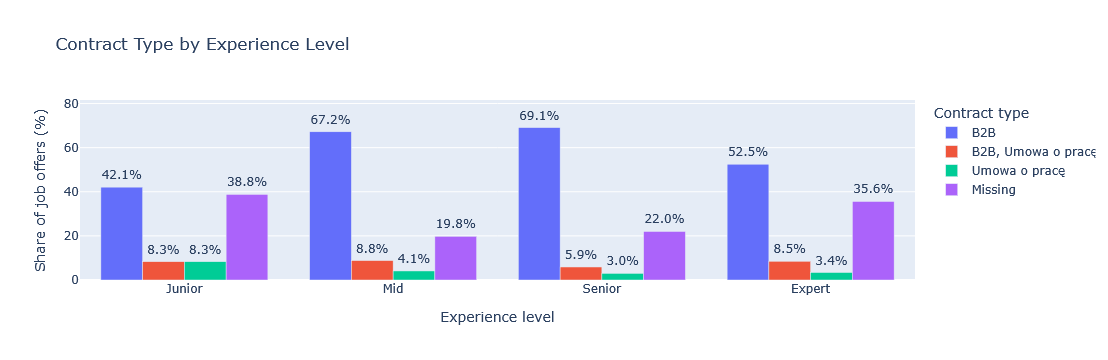

In [28]:
main_contract_types = [
    "B2B",
    "B2B, Umowa o pracę",
    "Umowa o pracę",
    "Missing"
]

contract_experience_plot = (
    contract_experience[
        main_contract_types
    ]
    .reset_index()
    .melt(
        id_vars="experience",
        var_name="contract_type",
        value_name="percentage"
    )
)

fig = px.bar(
    contract_experience_plot,
    x="experience",
    y="percentage",
    color="contract_type",
    barmode="group",
    text="percentage",
    category_orders={
        "experience": [
            "Junior",
            "Mid",
            "Senior",
            "Expert"
        ]
    },
    title="Contract Type by Experience Level",
    labels={
        "experience": "Experience level",
        "percentage": "Share of job offers (%)",
        "contract_type": "Contract type"
    }
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside"
)

fig.show()

### Key observations

B2B is the dominant contract type, appearing as the only reported contract option in 64.4% of all job offers. A further 7.0% of offers provide both B2B and an employment contract, while employment contracts alone account for only 3.5%.

Contract information is missing for 24.9% of the dataset. This substantial missing-data share should be considered when comparing employment arrangements.

B2B is particularly common among experienced candidates. It accounts for 69.1% of Senior and 67.2% of Mid-level offers. In comparison, B2B represents 42.1% of Junior offers.

Junior offers have the highest observed share of employment contracts, at 8.3%. However, contract information is missing for 38.8% of Junior positions, so this result should be interpreted cautiously.

Overall, the available data suggests that B2B is strongly associated with Mid and Senior recruitment, while Junior offers are more likely to provide an employment contract or omit contract information entirely.

## 6. Company Analysis

This section examines company-level recruitment activity, market concentration and differences between company-size segments.

### Company Data Quality

In [29]:
company_overview = pd.Series({
    "Job offers": len(df),
    "Company available": df["company"].notna().sum(),
    "Company missing": df["company"].isna().sum(),
    "Unique company names": df["company"].nunique(),
    "Company size available (%)": (
        df["company_size"].notna().mean() * 100
    ),
}).round(1)

company_overview

Job offers                    2856.0
Company available             2856.0
Company missing                  0.0
Unique company names           358.0
Company size available (%)      70.8
dtype: float64

In [30]:
df['company'].nunique()

358

In [31]:
company_mapping = {
    "Allegro sp. z o.o.": "Allegro",
    "DCG sp. z o.o.": "DCG",
    "Finture Sp. z o.o": "Finture",
    "Finture Sp. z o.o.": "Finture",
    "Iteamly": "iTeamly",
    "UNITY-T GROUP": "Unity-T Group",
    "Comscore (via CC)": "Comscore via CC"
}

df["company"] = df["company"].replace(company_mapping)

### Companies with the Highest Recruitment Activity

The ranking shows the number of unique offers published by each company. It represents job-posting activity on No Fluff Jobs rather than the total employment scale of an organization.

In [33]:
company_ranking = (
    df.dropna(subset=["company"])
    .groupby("company")
    .agg(
        job_offers=("job_id", "nunique")
    )
    .sort_values(
        "job_offers",
        ascending=False,
    )
)

company_ranking.head(10)

,job_offers
company,
Mindbox Sp. z o.o.,190
Antal,171
Link Group,140
Scalo,125
Upvanta,89
Square One Resources,87
Belvedere Recruitment,74
Ework Group,66
Verita HR,63


In [34]:
top_10_companies = (
    company_ranking
    .head(10)
    .sort_values(
        "job_offers",
        ascending=True,
    )
    .reset_index()
)

top_10_companies

,company,job_offers
0,Spyrosoft,61
1,Verita HR,63
2,Ework Group,66
3,Belvedere Recruitment,74
4,Square One Resources,87
5,Upvanta,89
6,Scalo,125
7,Link Group,140
8,Antal,171
9,Mindbox Sp. z o.o.,190


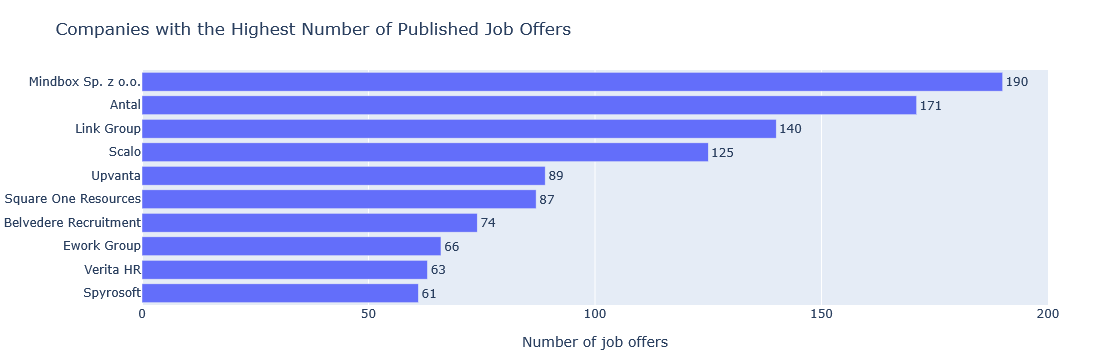

In [35]:

fig = px.bar(
    top_10_companies,
    x="job_offers",
    y="company",
    orientation="h",
    text="job_offers",
    title=(
        "Companies with the Highest Number "
        "of Published Job Offers"
    ),
    labels={
        "job_offers": "Number of job offers",
        "company": "Company",
    },
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    yaxis_title=None,
    showlegend=False,
    margin=dict(
        l=20,
        r=60,
        t=70,
        b=40,
    ),
)

fig.show()

In [36]:
company_offer_counts = (
    df.dropna(subset=["company"])
    .groupby("company")["job_id"]
    .nunique()
    .sort_values(ascending=False)
)

total_companies = company_offer_counts.size
total_offers_with_company = company_offer_counts.sum()

top_10_offers = company_offer_counts.head(10).sum()
top_20_offers = company_offer_counts.head(20).sum()

top_10_share = (
    top_10_offers
    / total_offers_with_company
    * 100
)

top_20_share = (
    top_20_offers
    / total_offers_with_company
    * 100
)

single_offer_companies = (
    company_offer_counts == 1
).sum()

single_offer_company_share = (
    single_offer_companies
    / total_companies
    * 100
)

median_offers_per_company = (
    company_offer_counts.median()
)

In [37]:
market_concentration = pd.DataFrame({
    "metric": [
        "Companies",
        "Offers with identified company",
        "Offers from Top 10 companies",
        "Offers from Top 10 companies (%)",
        "Offers from Top 20 companies",
        "Offers from Top 20 companies (%)",
        "Companies with one offer",
        "Companies with one offer (%)",
        "Median offers per company",
    ],
    "value": [
        total_companies,
        total_offers_with_company,
        top_10_offers,
        round(top_10_share, 1),
        top_20_offers,
        round(top_20_share, 1),
        single_offer_companies,
        round(single_offer_company_share, 1),
        median_offers_per_company,
    ],
})

market_concentration

,metric,value
0,Companies,352.0
1,Offers with identified company,2856.0
2,Offers from Top 10 companies,1066.0
3,Offers from Top 10 companies (%),37.3
4,Offers from Top 20 companies,1591.0
5,Offers from Top 20 companies (%),55.7
6,Companies with one offer,146.0
7,Companies with one offer (%),41.5
8,Median offers per company,2.0


### Key observation

Job-posting activity is strongly concentrated among a relatively small group of organizations. The 10 most active companies account for 37.3% of offers with an identified company, while the Top 20 account for 55.7%.

At the same time, 41.5% of companies published only one offer, and the median company published two offers. This indicates a long-tail distribution: a small number of highly active recruitment, consulting and outsourcing companies generate a substantial share of listings, while most organizations appear only occasionally.

These results describe the concentration of job postings observed on No Fluff Jobs and should not be interpreted as formal market shares of employers.

### Company Size Distribution

This section examines which company-size segments publish the most job offers. Company-size segments are based on the reported lower employee-count boundary.

In [38]:
company_size_order = [
    "Small",
    "Medium",
    "Large",
    "Enterprise",
    "Missing",
]

company_size_summary = (
    df["company_size_segment"]
    .value_counts()
    .reindex(
        company_size_order,
        fill_value=0,
    )
    .rename_axis("company_size_segment")
    .reset_index(name="job_offers")
)

company_size_summary["percentage"] = (
    company_size_summary["job_offers"]
    / len(df)
    * 100
).round(1)

company_size_summary

,company_size_segment,job_offers,percentage
0,Small,154,5.4
1,Medium,432,15.1
2,Large,776,27.2
3,Enterprise,660,23.1
4,Missing,834,29.2


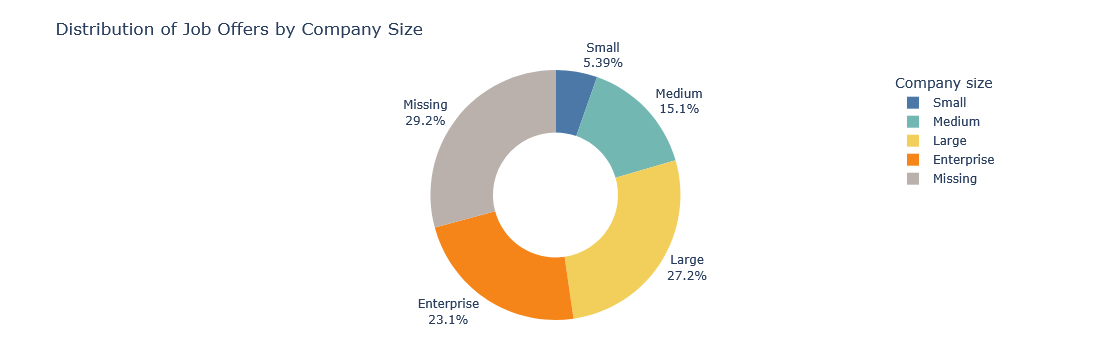

In [39]:
company_size_colors = {
    "Small": "#4C78A8",
    "Medium": "#72B7B2",
    "Large": "#F2CF5B",
    "Enterprise": "#F58518",
    "Missing": "#BAB0AC",
}

fig = px.pie(
    company_size_summary,
    names="company_size_segment",
    values="job_offers",
    hole=0.5,
    title="Distribution of Job Offers by Company Size",
    color="company_size_segment",
    color_discrete_map=company_size_colors,
    category_orders={
        "company_size_segment": company_size_order,
    },
)

fig.update_traces(
    textinfo="percent+label",
    textposition="outside",
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Job offers: %{value}<br>"
        "Share: %{percent}"
        "<extra></extra>"
    ),
)

fig.update_layout(
    showlegend=True,
    legend_title_text="Company size",
    margin=dict(
        l=40,
        r=40,
        t=70,
        b=40,
    ),
)

fig.show()

In [40]:
company_size_order = [
    "Small",
    "Medium",
    "Large",
    "Enterprise",
]

### Company Size by Experience Level

This section compares the experience-level distribution within each company-size segment.

> Are smaller companies more likely to hire experienced candidates than larger organizations?

In [41]:
experience_order = [
    "Junior",
    "Mid",
    "Senior",
    "Expert",
    "Missing",
]

company_experience_df = (
    df.loc[
        df["company_size_segment"].isin(
            company_size_order
        )
    ]
    .assign(
        experience=lambda data:
            data["experience"].fillna("Missing")
    )
)

In [42]:
company_experience = (
    pd.crosstab(
        company_experience_df["company_size_segment"],
        company_experience_df["experience"],
        normalize="index",
    )
    .mul(100)
    .round(1)
    .reindex(
        index=company_size_order,
        columns=experience_order,
        fill_value=0,
    )
)

company_experience

experience,Junior,Mid,Senior,Expert,Missing
company_size_segment,,,,,
Small,7.1,24.7,63.6,3.9,0.6
Medium,2.8,50.9,43.5,2.5,0.2
Large,1.7,37.6,56.7,3.5,0.5
Enterprise,7.1,31.8,52.0,6.7,2.4


In [43]:
company_experience_plot = (
    company_experience
    .reset_index()
    .melt(
        id_vars="company_size_segment",
        var_name="experience",
        value_name="percentage",
    )
)

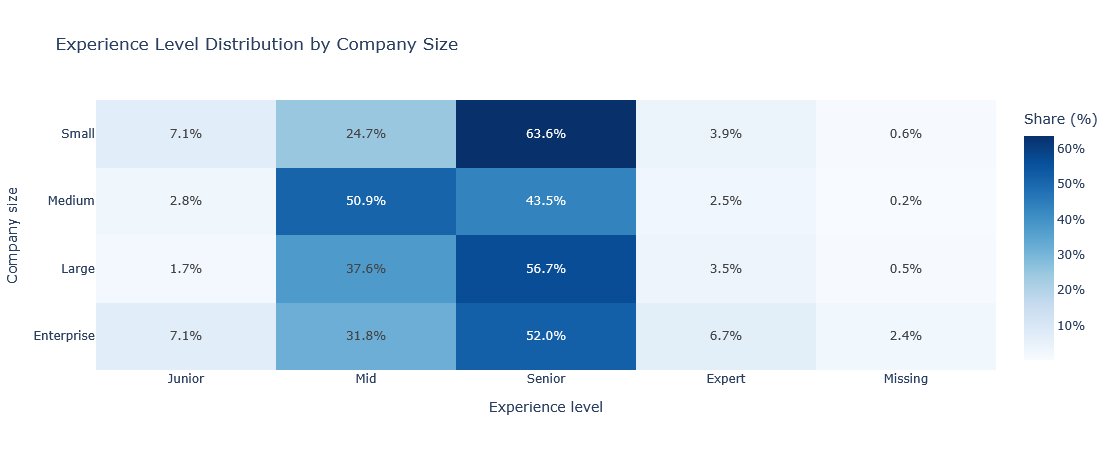

In [44]:
fig = px.imshow(
    company_experience,
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale="Blues",
    title="Experience Level Distribution by Company Size",
    labels={
        "x": "Experience level",
        "y": "Company size",
        "color": "Share of offers (%)",
    },
)

fig.update_traces(
    texttemplate="%{z:.1f}%",
    hovertemplate=(
        "Company size: %{y}<br>"
        "Experience: %{x}<br>"
        "Share: %{z:.1f}%"
        "<extra></extra>"
    ),
)

fig.update_layout(
    height=450,
    xaxis_side="bottom",
    coloraxis_colorbar=dict(
        title="Share (%)",
        ticksuffix="%",
    ),
)

fig.show()

### Company Size by Workplace Model

This section examines how remote, hybrid and onsite work arrangements differ across company-size segments.

> Which company sizes offer the greatest workplace flexibility?

In [45]:
workplace_order = [
    "Remote",
    "Hybrid",
    "Onsite",
    "Missing",
]

company_workplace_df = (
    df.loc[
        df["company_size_segment"].isin(
            company_size_order
        )
    ]
    .assign(
        workplace=lambda data:
            data["workplace"].fillna("Missing")
    )
)

In [46]:
company_workplace = (
    pd.crosstab(
        company_workplace_df["company_size_segment"],
        company_workplace_df["workplace"],
        normalize="index",
    )
    .mul(100)
    .round(1)
    .reindex(
        index=company_size_order,
        columns=workplace_order,
        fill_value=0,
    )
)

company_workplace

workplace,Remote,Hybrid,Onsite,Missing
company_size_segment,,,,
Small,66.9,26.0,0.6,6.5
Medium,41.7,43.1,0.2,15.0
Large,40.5,52.1,0.0,7.5
Enterprise,20.8,72.4,0.0,6.8


In [47]:
company_workplace_plot = (
    company_workplace
    .reset_index()
    .melt(
        id_vars="company_size_segment",
        var_name="workplace",
        value_name="percentage",
    )
)

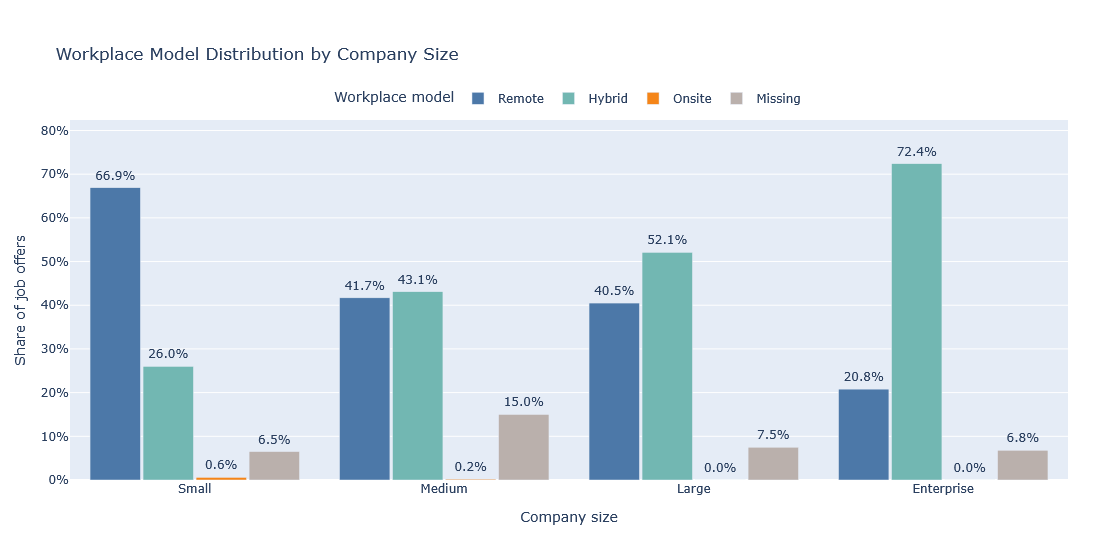

In [48]:
workplace_order = [
    "Remote",
    "Hybrid",
    "Onsite",
    "Missing",
]

workplace_colors = {
    "Remote": "#4C78A8",
    "Hybrid": "#72B7B2",
    "Onsite": "#F58518",
    "Missing": "#BAB0AC",
}

company_workplace_plot["label"] = (
    company_workplace_plot["percentage"]
    .apply(lambda value: f"{value:.1f}%")
)

fig = px.bar(
    company_workplace_plot,
    x="company_size_segment",
    y="percentage",
    color="workplace",
    text="label",
    barmode="group",
    category_orders={
        "company_size_segment": company_size_order,
        "workplace": workplace_order,
    },
    color_discrete_map=workplace_colors,
    title="Workplace Model Distribution by Company Size",
    labels={
        "company_size_segment": "Company size",
        "percentage": "Share of job offers (%)",
        "workplace": "Workplace model",
    },
)

fig.update_traces(
    texttemplate="%{text}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "Company size: %{x}<br>"
        "Share: %{y:.1f}%"
        "<extra></extra>"
    ),
)

fig.update_layout(
    width=1050,
    height=550,
    bargap=0.15,
    bargroupgap=0.05,
    yaxis=dict(
        title="Share of job offers",
        ticksuffix="%",
        range=[
            0,
            company_workplace_plot["percentage"].max() + 10,
        ],
    ),
    xaxis=dict(
        title="Company size",
        categoryorder="array",
        categoryarray=company_size_order,
    ),
    legend=dict(
        title="Workplace model",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5,
    ),
    uniformtext_minsize=8,
    uniformtext_mode="show",
    margin=dict(
        l=70,
        r=40,
        t=120,
        b=70,
    ),
)

fig.show()

### Company Size by Contract Type

This section compares the most common contract options across company-size segments. Contract combinations are preserved because a single job offer may provide more than one employment option.

In [49]:
main_contract_mapping = {
    "B2B": "B2B",
    "Umowa o pracę": "UoP",
    "B2B, Umowa o pracę": "B2B + UoP",
}

df["contract_group"] = (
    df["contract_type"]
    .map(main_contract_mapping)
)

df["contract_group"] = (
    df["contract_group"]
    .where(
        df["contract_type"].isna()
        | df["contract_group"].notna(),
        "Other",
    )
    .fillna("Missing")
)

In [50]:
contract_order = [
    "B2B",
    "UoP",
    "B2B + UoP",
    "Other",
    "Missing",
]

In [51]:
company_contract_df = (
    df.loc[
        df["company_size_segment"].isin(
            company_size_order
        )
    ]
)

company_contract = (
    pd.crosstab(
        company_contract_df["company_size_segment"],
        company_contract_df["contract_group"],
        normalize="index",
    )
    .mul(100)
    .round(1)
    .reindex(
        index=company_size_order,
        columns=contract_order,
        fill_value=0,
    )
)

company_contract

contract_group,B2B,UoP,B2B + UoP,Other,Missing
company_size_segment,,,,,
Small,84.4,1.3,1.3,0.0,13.0
Medium,80.1,2.5,2.8,0.2,14.4
Large,83.9,3.7,0.5,0.0,11.9
Enterprise,42.9,4.8,0.6,0.2,51.5


In [52]:
company_contract_plot = (
    company_contract
    .reset_index()
    .melt(
        id_vars="company_size_segment",
        var_name="contract_group",
        value_name="percentage",
    )
)

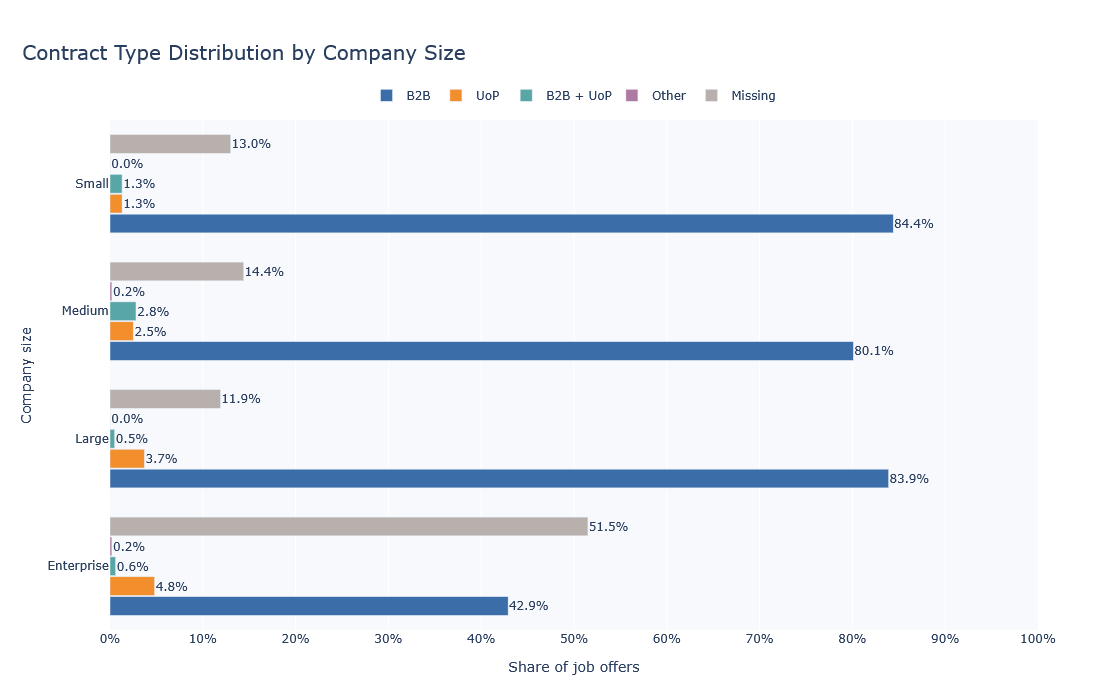

In [53]:
contract_order = [
    "B2B",
    "UoP",
    "B2B + UoP",
    "Other",
    "Missing",
]

contract_colors = {
    "B2B": "#3B6EA8",
    "UoP": "#F28E2B",
    "B2B + UoP": "#59A6A6",
    "Other": "#AF7AA1",
    "Missing": "#B8B0AD",
}

company_contract_plot["label"] = (
    company_contract_plot["percentage"]
    .apply(lambda value: f"{value:.1f}%")
)

fig = px.bar(
    company_contract_plot,
    x="percentage",
    y="company_size_segment",
    color="contract_group",
    text="label",
    orientation="h",
    barmode="group",
    category_orders={
        "company_size_segment": company_size_order,
        "contract_group": contract_order,
    },
    color_discrete_map=contract_colors,
    title="Contract Type Distribution by Company Size",
    labels={
        "company_size_segment": "Company size",
        "percentage": "Share of job offers (%)",
        "contract_group": "Contract type",
    },
)

fig.update_traces(
    texttemplate="%{text}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "Company size: %{y}<br>"
        "Share of offers: %{x:.1f}%"
        "<extra></extra>"
    ),
)

fig.update_layout(
    width=1200,
    height=700,
    bargap=0.22,
    bargroupgap=0.06,
    plot_bgcolor="#F7F9FC",
    paper_bgcolor="white",
    title=dict(
        x=0.02,
        xanchor="left",
        font=dict(size=20),
    ),
    xaxis=dict(
        title="Share of job offers",
        range=[0, 100],
        tickmode="linear",
        tick0=0,
        dtick=10,
        ticksuffix="%",
        gridcolor="white",
        zeroline=False,
    ),
    yaxis=dict(
        title="Company size",
        categoryorder="array",
        categoryarray=list(
            reversed(company_size_order)
        ),
    ),
    legend=dict(
        title=None,
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5,
    ),
    uniformtext_minsize=8,
    uniformtext_mode="show",
    margin=dict(
        l=110,
        r=70,
        t=120,
        b=70,
    ),
)

fig.show()

### Key observations

Large companies publish the highest share of job offers, accounting for 27.2% of the dataset. Enterprise organizations represent 23.1%, while Medium and Small companies account for 15.1% and 5.4% respectively. Company size is unavailable for 29.2% of offers, which limits the representativeness of comparisons between segments.

Small companies show the strongest preference for Senior candidates, who represent 63.6% of their offers. Large and Enterprise organizations are also primarily oriented toward Senior professionals. Medium companies differ from the other segments because Mid-level positions form their largest group, accounting for 50.9% of offers.

Junior opportunities remain limited in most company-size segments. Junior roles account for only 1.7% of Large-company offers and 2.8% of Medium-company offers. Their share is higher among Small and Enterprise organizations, at 7.1% in both segments.

Workplace models differ substantially by company size. Remote work is most common among Small companies, representing 66.9% of their offers. Its share decreases as company size increases, reaching 20.8% among Enterprise organizations. In contrast, hybrid work rises from 26.0% among Small companies to 72.4% among Enterprise organizations.

B2B dominates Small, Medium and Large companies, accounting for approximately 80–84% of their offers. Enterprise organizations have a lower observed B2B share of 42.9%, but contract information is missing for 51.5% of Enterprise offers. Therefore, this difference should not be interpreted as evidence that Enterprise companies generally use B2B contracts less frequently.

Overall, smaller companies appear to provide greater access to fully remote work and show a strong preference for Senior candidates. Larger organizations, especially Enterprise companies, are considerably more likely to use hybrid workplace models.

### Profile of the Most Active Companies

This table summarizes the recruitment profiles of the ten companies with the highest number of published job offers.

In [54]:
def most_common_value(series):
    values = series.dropna()

    if values.empty:
        return "Missing"

    return values.mode().iloc[0]

In [55]:
top_company_names = (
    df.dropna(subset=["company"])
    .groupby("company")["job_id"]
    .nunique()
    .nlargest(10)
    .index
)

In [56]:
top_company_profiles = (
    df[df["company"].isin(top_company_names)]
    .groupby("company")
    .agg(
        job_offers=("job_id", "nunique"),
        dominant_category=(
            "category",
            most_common_value,
        ),
        dominant_experience=(
            "experience",
            most_common_value,
        ),
        dominant_workplace=(
            "workplace",
            most_common_value,
        ),
        dominant_company_size=(
            "company_size_segment",
            most_common_value,
        ),
    )
    .sort_values(
        "job_offers",
        ascending=False,
    )
    .reset_index()
)

top_company_profiles

,company,job_offers,dominant_category,dominant_experience,dominant_workplace,dominant_company_size
0,Mindbox Sp. z o.o.,190,Backend,Senior,Hybrid,Missing
1,Antal,171,Security,Mid,Hybrid,Medium
2,Link Group,140,Project Manager,Senior,Remote,Large
3,Scalo,125,Backend,Senior,Hybrid,Large
4,Upvanta,89,Backend,Mid,Remote,Missing
5,Square One Resources,87,Data,Senior,Remote,Small
6,Belvedere Recruitment,74,Backend,Senior,Hybrid,Missing
7,Ework Group,66,Project Manager,Senior,Hybrid,Large
8,Verita HR,63,Data,Senior,Hybrid,Large
9,Deloitte,61,ERP,Senior,Hybrid,Enterprise


### Key observations

Mindbox shows the highest recruitment activity, with 190 unique job offers, followed by Antal with 171 and Link Group with 140.

The ranking is dominated by recruitment, consulting and outsourcing companies. These organizations may publish vacancies on behalf of multiple clients, so their high position does not necessarily represent internal hiring demand or company growth.

Senior positions are the dominant experience level for eight of the ten most active companies. Antal and Upvanta are the exceptions, with Mid-level roles appearing most frequently in their offers.

Hybrid work is the most common workplace model for seven of the ten companies. Link Group, Upvanta and Square One Resources publish predominantly remote positions.

Backend is the most common dominant category, leading the recruitment profile of Mindbox, Scalo, Upvanta and Belvedere Recruitment. Project Manager and Data positions are also prominent among several highly active companies.

The results describe recruitment activity observed on No Fluff Jobs rather than the overall scale of employment within these organizations.